# Sentenced Differently: Regression Analysis

**Project:** Racial and Gender Disparities in Federal Sentencing (FY2020-FY2024)  
**Sample:** Core sample excludes immigration cases (n ≈ 191K); immigration analyzed separately  
**Outcome:** `LOG_SENTENCE` = log(sentence months), life sentences coded as 470 months  

## Model Specifications

| Model | Formula |
|---|---|
| **M1** Baseline | log(sentence) ~ Race + Sex + Age |
| **M2** Legal Controls | M1 + Offense Level + Criminal History + Guideline Min + Mandatory Min + Guilty Plea + Accept Resp |
| **M3** Interactions | M2 + Race × Sex |
| **M4** Full Spec | M3 + District FE + Fiscal Year FE |

All OLS models use HC1 heteroskedasticity-robust standard errors.  
Reference category: **White Male** in all models.

In [1]:
import sys, os
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath('')).parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.formula.api as smf

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)
%matplotlib inline
sns.set_theme(style='whitegrid', font_scale=1.1)

print(f'Working directory: {os.getcwd()}')

Working directory: /Users/latahviawilliams/s26-sentenced-differently


---
## 1. Load Data & Prepare Analysis Samples

In [2]:
from src.regression import prep_sample

df = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'ussc_fy2020_fy2024.parquet')
print(f'Full dataset: {len(df):,} rows')
core, imm = prep_sample(df)
print(f'\nCore sample columns: {list(core.columns)}')

Full dataset: 284,823 rows
Core sample: 191,460 → 188,873 after dropping missing essentials
Immigration sample: 92,996

Core sample columns: ['ZONE', 'SENTTOT', 'SENSPLT0', 'USSCIDN', 'ACCAP', 'ACCTRESP', 'AGE', 'AGECAT', 'CIRCDIST', 'DISPOSIT', 'DISTRICT', 'DSPLEA', 'EDUCATN', 'HISPORIG', 'INOUT', 'MONRACE', 'MONSEX', 'NEWCIT', 'NEWEDUC', 'NEWRACE', 'NOCOUNTS', 'OFFGUIDE', 'SENTMON', 'SENTRNGE', 'XCRHISSR', 'XFOLSOR', 'XMAXSOR', 'XMINSOR', 'FISCALYR', 'RACE', 'SEX', 'CRIM_HIST', 'ZONE_LABEL', 'SENTENCE_TYPE', 'OFFENSE_CAT', 'OFFENSE_GROUP', 'IS_IMMIGRATION', 'IS_LIFE', 'SENTENCE_MONTHS', 'INCARCERATED', 'LOG_SENTENCE', 'MAND_MIN', 'GUILTY_PLEA', 'TRIAL', 'ACCEPT_RESP', 'RACE_BLACK', 'RACE_HISPANIC', 'RACE_OTHER', 'FEMALE']


In [3]:
# Summary of analysis variables
analysis_vars = ['LOG_SENTENCE','RACE_BLACK','RACE_HISPANIC','RACE_OTHER',
                 'FEMALE','AGE','XFOLSOR','XCRHISSR','XMINSOR','MAND_MIN',
                 'GUILTY_PLEA','ACCEPT_RESP']
print('Core sample descriptive stats:')
core[analysis_vars].describe().round(3)

Core sample descriptive stats:


,LOG_SENTENCE,RACE_BLACK,RACE_HISPANIC,RACE_OTHER,FEMALE,AGE,XFOLSOR,XCRHISSR,XMINSOR,MAND_MIN,GUILTY_PLEA,ACCEPT_RESP
count,188873.0000,188873.0000,188873.0000,188873.0000,188873.0000,188873.0000,188873.0000,188873.0000,188873.0000,188873.0000,188873.0000,188873.0000
mean,3.4670,0.3360,0.3170,0.0570,0.1310,37.3270,23.5610,2.7530,249.0940,0.9780,0.9620,0.9450
std,2.0000,0.4720,0.4650,0.2310,0.3370,11.1620,8.5440,1.8430,1267.9280,0.1460,0.1920,0.2260
min,-3.5070,0.0000,0.0000,0.0000,0.0000,18.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000
25%,3.1780,0.0000,0.0000,0.0000,0.0000,29.0000,17.0000,1.0000,30.0000,1.0000,1.0000,1.0000
50%,3.9120,0.0000,0.0000,0.0000,0.0000,36.0000,23.0000,2.0000,63.0000,1.0000,1.0000,1.0000
75%,4.6050,1.0000,1.0000,0.0000,0.0000,44.0000,29.0000,4.0000,121.0000,1.0000,1.0000,1.0000
max,8.8820,1.0000,1.0000,1.0000,1.0000,93.0000,43.0000,6.0000,9996.0000,1.0000,1.0000,1.0000


---
## 2. Model 1 — Baseline (Race + Sex + Age)

In [4]:
from src.regression import run_model1, pct_effect, extract_coefs

m1 = run_model1(core)
print(m1.summary2(alpha=0.05).tables[1].round(4))

                Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
Intercept      3.8398    0.0207 185.9122 0.0000  3.7994  3.8803
RACE_BLACK    -0.0233    0.0120  -1.9442 0.0519 -0.0468  0.0002
RACE_HISPANIC -0.1835    0.0122 -15.0769 0.0000 -0.2074 -0.1597
RACE_OTHER    -0.4379    0.0232 -18.8945 0.0000 -0.4834 -0.3925
FEMALE        -1.0407    0.0168 -61.9653 0.0000 -1.0736 -1.0078
AGE           -0.0039    0.0005  -8.5049 0.0000 -0.0048 -0.0030


In [5]:
print('Model 1 — % sentence difference from White Male baseline:')
for var in ['RACE_BLACK','RACE_HISPANIC','RACE_OTHER','FEMALE']:
    if var in m1.params:
        c, p = m1.params[var], m1.pvalues[var]
        stars = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else ''
        print(f'  {var:22s}: {pct_effect(c):+6.1f}%  (p={p:.4f}) {stars}')
print(f'\nR² = {m1.rsquared:.4f}   N = {int(m1.nobs):,}')

Model 1 — % sentence difference from White Male baseline:
  RACE_BLACK            :   -2.3%  (p=0.0519) 
  RACE_HISPANIC         :  -16.8%  (p=0.0000) ***
  RACE_OTHER            :  -35.5%  (p=0.0000) ***
  FEMALE                :  -64.7%  (p=0.0000) ***

R² = 0.0351   N = 188,873


---
## 3. Model 2 — Legal Controls Added

In [6]:
from src.regression import run_model2

m2 = run_model2(core)
print('Model 2 key coefficients:')
key = ['RACE_BLACK','RACE_HISPANIC','RACE_OTHER','FEMALE',
       'AGE','XFOLSOR','XCRHISSR','XMINSOR','MAND_MIN','GUILTY_PLEA','ACCEPT_RESP']
tbl = extract_coefs(m2, 'Model 2')
print(tbl.to_string(index=False))
print(f'\nR² = {m2.rsquared:.4f}   N = {int(m2.nobs):,}')

Model 2 key coefficients:
  Model      Variable    Coef     SE        t  p-value  CI_low  CI_high Sig
Model 2    RACE_BLACK  0.0946 0.0098   9.6400   0.0000  0.0754   0.1138 ***
Model 2 RACE_HISPANIC  0.0104 0.0102   1.0160   0.3099 -0.0096   0.0303    
Model 2    RACE_OTHER -0.0352 0.0187  -1.8770   0.0606 -0.0719   0.0016   .
Model 2        FEMALE -0.6723 0.0143 -47.1260   0.0000 -0.7002  -0.6443 ***
Model 2           AGE -0.0097 0.0004 -25.6290   0.0000 -0.0105  -0.0090 ***
Model 2       XFOLSOR  0.1213 0.0005 236.6290   0.0000  0.1203   0.1223 ***
Model 2      XCRHISSR  0.2378 0.0020 118.5250   0.0000  0.2339   0.2417 ***
Model 2       XMINSOR -0.0000 0.0000  -6.9890   0.0000 -0.0000  -0.0000 ***
Model 2      MAND_MIN  0.6028 0.0399  15.0920   0.0000  0.5245   0.6811 ***
Model 2   GUILTY_PLEA -0.1188 0.0264  -4.5080   0.0000 -0.1705  -0.0672 ***
Model 2   ACCEPT_RESP -0.2469 0.0225 -10.9720   0.0000 -0.2910  -0.2028 ***

R² = 0.3626   N = 188,873


In [7]:
print('Model 2 — % sentence difference (after legal controls):')
for var in ['RACE_BLACK','RACE_HISPANIC','RACE_OTHER','FEMALE']:
    if var in m2.params:
        c, p = m2.params[var], m2.pvalues[var]
        stars = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else ''
        print(f'  {var:22s}: {pct_effect(c):+6.1f}%  (p={p:.4f}) {stars}')

Model 2 — % sentence difference (after legal controls):
  RACE_BLACK            :   +9.9%  (p=0.0000) ***
  RACE_HISPANIC         :   +1.0%  (p=0.3099) 
  RACE_OTHER            :   -3.5%  (p=0.0606) 
  FEMALE                :  -49.0%  (p=0.0000) ***


---
## 4. Model 3 — Race × Sex Interactions

In [8]:
from src.regression import run_model3

m3 = run_model3(core)
tbl = extract_coefs(m3, 'Model 3')
print(tbl.to_string(index=False))
print(f'\nR² = {m3.rsquared:.4f}   N = {int(m3.nobs):,}')

  Model             Variable    Coef     SE        t  p-value  CI_low  CI_high Sig
Model 3           RACE_BLACK  0.1353 0.0098  13.8040   0.0000  0.1161   0.1545 ***
Model 3        RACE_HISPANIC  0.0249 0.0105   2.3800   0.0173  0.0044   0.0454   *
Model 3           RACE_OTHER -0.0321 0.0194  -1.6520   0.0986 -0.0702   0.0060   .
Model 3               FEMALE -0.5680 0.0225 -25.2790   0.0000 -0.6121  -0.5240 ***
Model 3    RACE_BLACK:FEMALE -0.3786 0.0418  -9.0550   0.0000 -0.4606  -0.2967 ***
Model 3 RACE_HISPANIC:FEMALE -0.0802 0.0319  -2.5110   0.0120 -0.1428  -0.0176   *
Model 3    RACE_OTHER:FEMALE -0.0155 0.0593  -0.2610   0.7941 -0.1316   0.1007    
Model 3                  AGE -0.0095 0.0004 -25.1050   0.0000 -0.0103  -0.0088 ***
Model 3              XFOLSOR  0.1211 0.0005 236.3970   0.0000  0.1201   0.1221 ***
Model 3             XCRHISSR  0.2355 0.0020 117.4730   0.0000  0.2316   0.2394 ***
Model 3              XMINSOR -0.0000 0.0000  -6.7700   0.0000 -0.0000  -0.0000 ***
Mode

In [9]:
print('Model 3 — Race x Sex interaction % effects:')
for var in ['RACE_BLACK:FEMALE','RACE_HISPANIC:FEMALE','RACE_OTHER:FEMALE']:
    if var in m3.params:
        c, p = m3.params[var], m3.pvalues[var]
        stars = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'ns'
        print(f'  {var:30s}: {pct_effect(c):+6.1f}%  (p={p:.4f}) {stars}')

Model 3 — Race x Sex interaction % effects:
  RACE_BLACK:FEMALE             :  -31.5%  (p=0.0000) ***
  RACE_HISPANIC:FEMALE          :   -7.7%  (p=0.0120) *
  RACE_OTHER:FEMALE             :   -1.5%  (p=0.7941) ns


---
## 5. Model 4 — Full Specification (+ District & Year FE)

In [10]:
from src.regression import run_model4

m4 = run_model4(core)
tbl = extract_coefs(m4, 'Model 4')
print(tbl.to_string(index=False))
print(f'\nR² = {m4.rsquared:.4f}   Adj. R² = {m4.rsquared_adj:.4f}   N = {int(m4.nobs):,}')

  Model             Variable    Coef     SE        t  p-value  CI_low  CI_high Sig
Model 4           RACE_BLACK  0.1517 0.0100  15.1570   0.0000  0.1321   0.1713 ***
Model 4        RACE_HISPANIC  0.0592 0.0113   5.2470   0.0000  0.0371   0.0814 ***
Model 4           RACE_OTHER  0.0589 0.0204   2.8820   0.0039  0.0188   0.0989  **
Model 4               FEMALE -0.5903 0.0214 -27.6490   0.0000 -0.6322  -0.5485 ***
Model 4    RACE_BLACK:FEMALE -0.3694 0.0401  -9.2070   0.0000 -0.4480  -0.2907 ***
Model 4 RACE_HISPANIC:FEMALE -0.0231 0.0307  -0.7540   0.4506 -0.0832   0.0370    
Model 4    RACE_OTHER:FEMALE  0.0157 0.0565   0.2770   0.7815 -0.0951   0.1265    
Model 4                  AGE -0.0081 0.0004 -22.0560   0.0000 -0.0088  -0.0074 ***
Model 4              XFOLSOR  0.1203 0.0005 239.4220   0.0000  0.1194   0.1213 ***
Model 4             XCRHISSR  0.2255 0.0020 114.6490   0.0000  0.2216   0.2293 ***
Model 4              XMINSOR -0.0000 0.0000  -5.9560   0.0000 -0.0000  -0.0000 ***
Mode

In [11]:
print('Model 4 — % sentence difference (full specification):')
for var in ['RACE_BLACK','RACE_HISPANIC','RACE_OTHER','FEMALE',
            'RACE_BLACK:FEMALE','RACE_HISPANIC:FEMALE','RACE_OTHER:FEMALE']:
    if var in m4.params:
        c, p = m4.params[var], m4.pvalues[var]
        stars = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'ns'
        print(f'  {var:30s}: {pct_effect(c):+6.1f}%  (p={p:.4f}) {stars}')

Model 4 — % sentence difference (full specification):
  RACE_BLACK                    :  +16.4%  (p=0.0000) ***
  RACE_HISPANIC                 :   +6.1%  (p=0.0000) ***
  RACE_OTHER                    :   +6.1%  (p=0.0039) **
  FEMALE                        :  -44.6%  (p=0.0000) ***
  RACE_BLACK:FEMALE             :  -30.9%  (p=0.0000) ***
  RACE_HISPANIC:FEMALE          :   -2.3%  (p=0.4506) ns
  RACE_OTHER:FEMALE             :   +1.6%  (p=0.7815) ns


---
## 6. Model Comparison Table

In [12]:
from src.regression import model_comparison_table

models = {'Model 1': m1, 'Model 2': m2, 'Model 3': m3, 'Model 4': m4}
comparison = model_comparison_table(models)
print('Model Comparison — Key Coefficients (coef*** / (SE))')
print('Note: *** p<.001  ** p<.01  * p<.05')
print()
comparison

Model Comparison — Key Coefficients (coef*** / (SE))
Note: *** p<.001  ** p<.01  * p<.05



,Model 1,Model 2,Model 3,Model 4
Variable,,,,
RACE_BLACK,-0.023.\n(0.012),0.095***\n(0.010),0.135***\n(0.010),0.152***\n(0.010)
RACE_HISPANIC,-0.184***\n(0.012),0.010\n(0.010),0.025*\n(0.010),0.059***\n(0.011)
RACE_OTHER,-0.438***\n(0.023),-0.035.\n(0.019),-0.032.\n(0.019),0.059**\n(0.020)
FEMALE,-1.041***\n(0.017),-0.672***\n(0.014),-0.568***\n(0.022),-0.590***\n(0.021)
RACE_BLACK:FEMALE,—,—,-0.379***\n(0.042),-0.369***\n(0.040)
RACE_HISPANIC:FEMALE,—,—,-0.080*\n(0.032),-0.023\n(0.031)
R²,0.0351,0.3626,0.3632,0.4110
N,"188,873","188,873","188,873","188,873"


---
## 7. Logistic Regression — Incarceration Decision

In [13]:
from src.regression import run_logit

logit = run_logit(core)
key_vars = ['RACE_BLACK','RACE_HISPANIC','RACE_OTHER','FEMALE',
            'AGE','XFOLSOR','XCRHISSR','MAND_MIN','GUILTY_PLEA','ACCEPT_RESP']

logit_summary = pd.DataFrame({
    'Log-Odds': logit.params,
    'Odds Ratio': np.exp(logit.params),
    'SE': logit.bse,
    'p-value': logit.pvalues,
}).loc[lambda d: d.index.isin(key_vars)].round(4)
logit_summary['Sig'] = logit_summary['p-value'].apply(
    lambda p: '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else ''
)
print('Logistic Regression: P(Incarcerated) — Odds Ratios')
print('Pseudo R²:', round(logit.prsquared, 4), '   N:', int(logit.nobs))
print()
logit_summary

Logistic Regression: P(Incarcerated) — Odds Ratios


Pseudo R²: 0.2398    N: 188873



,Log-Odds,Odds Ratio,SE,p-value,Sig
RACE_BLACK,0.1336,1.1429,0.0287,0.0000,***
RACE_HISPANIC,0.1199,1.1274,0.0301,0.0001,***
RACE_OTHER,0.2229,1.2497,0.0453,0.0000,***
FEMALE,-0.8802,0.4147,0.0246,0.0000,***
AGE,-0.0095,0.9905,0.0009,0.0000,***
XFOLSOR,0.1197,1.1272,0.0017,0.0000,***
XCRHISSR,0.3843,1.4686,0.0079,0.0000,***
MAND_MIN,0.3057,1.3575,0.0463,0.0000,***
GUILTY_PLEA,-0.2753,0.7594,0.1067,0.0099,**
ACCEPT_RESP,-0.6280,0.5337,0.0922,0.0000,***


---
## 8. Subgroup Analysis by Offense Category

In [14]:
from src.regression import run_subgroup_models

print('Running subgroup models...')
subgroup_models = run_subgroup_models(core, imm)

Running subgroup models...
  Drug Trafficking: N=87,935


  Firearms: N=37,681


  Fraud/Economic: N=18,141


  Immigration: N=92,996


In [15]:
# Subgroup coefficient comparison table
focus = ['RACE_BLACK','RACE_HISPANIC','RACE_OTHER','FEMALE']
rows = []
for sg_name, res in subgroup_models.items():
    row = {'Subgroup': sg_name, 'N': f"{int(res.nobs):,}", 'R²': f"{res.rsquared:.3f}"}
    for var in focus:
        if var in res.params:
            c, p = res.params[var], res.pvalues[var]
            stars = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else ''
            row[var] = f"{pct_effect(c):+.1f}%{stars}"
        else:
            row[var] = '—'
    rows.append(row)

sg_tbl = pd.DataFrame(rows).set_index('Subgroup')
print('Subgroup Results — % Sentence Difference (Model 4 spec)')
print('Reference: White Male | *** p<.001  ** p<.01  * p<.05')
print()
sg_tbl

Subgroup Results — % Sentence Difference (Model 4 spec)
Reference: White Male | *** p<.001  ** p<.01  * p<.05



,N,R²,RACE_BLACK,RACE_HISPANIC,RACE_OTHER,FEMALE
Subgroup,,,,,,
Drug Trafficking,"87,935",0.358,+28.3%***,+30.8%***,+0.7%,-41.6%***
Firearms,"37,681",0.345,+16.9%***,+14.4%***,+9.8%,-46.2%***
Fraud/Economic,"18,141",0.327,+13.3%**,+7.3%,-3.5%,-14.3%**
Immigration,"86,604",0.370,+7.2%,+19.8%***,-3.4%,-16.8%*


---
## 9. Coefficient Plot — Race & Gender Effects Across Models

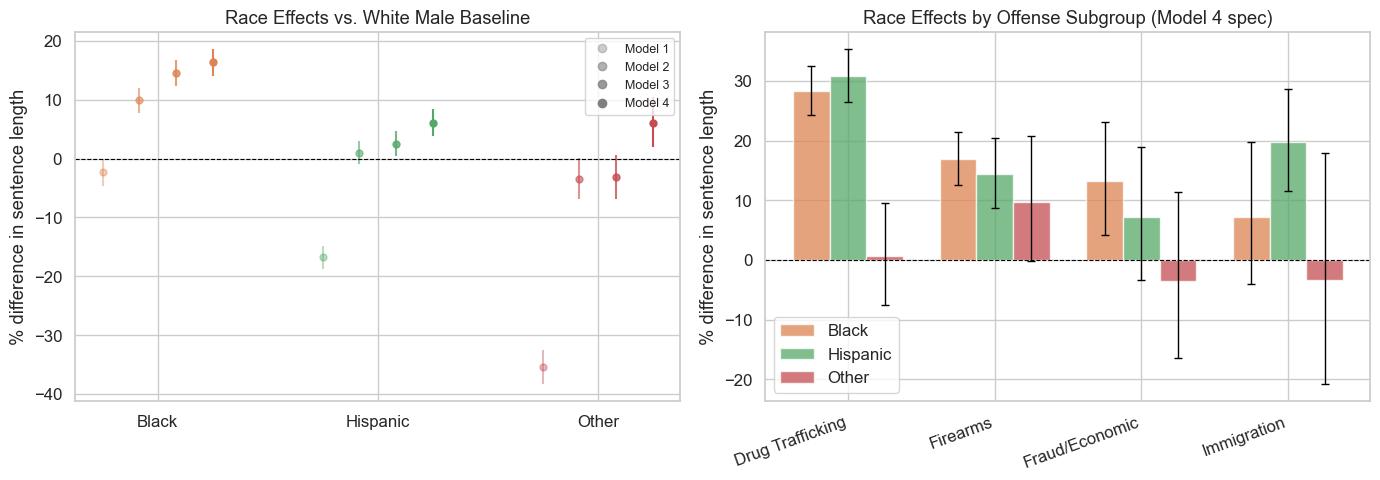

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

race_vars = ['RACE_BLACK', 'RACE_HISPANIC', 'RACE_OTHER']
labels    = ['Black', 'Hispanic', 'Other']
colors    = ['#DD8452', '#55A868', '#C44E52']
model_names = ['Model 1', 'Model 2', 'Model 3', 'Model 4']
model_list  = [m1, m2, m3, m4]
offsets = np.linspace(-0.25, 0.25, 4)

# Left panel: race effects
ax = axes[0]
for mi, (mname, res) in enumerate(zip(model_names, model_list)):
    for vi, (var, lbl, col) in enumerate(zip(race_vars, labels, colors)):
        if var in res.params:
            c  = pct_effect(res.params[var])
            ci = res.conf_int().loc[var]
            lo = pct_effect(ci[0])
            hi = pct_effect(ci[1])
            x  = vi + offsets[mi]
            ax.errorbar(x, c, yerr=[[c-lo],[hi-c]],
                        fmt='o', color=col,
                        alpha=0.4 + 0.2*mi, markersize=5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(range(len(race_vars)))
ax.set_xticklabels(labels)
ax.set_ylabel('% difference in sentence length')
ax.set_title('Race Effects vs. White Male Baseline')
# Legend for models
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', color='grey',
                  alpha=0.4+0.2*i, label=m, linestyle='')
           for i, m in enumerate(model_names)]
ax.legend(handles=handles, fontsize=9)

# Right panel: subgroup race effects from Model 4 spec
ax = axes[1]
sg_names = list(subgroup_models.keys())
x_pos = np.arange(len(sg_names))
width = 0.25
for vi, (var, lbl, col) in enumerate(zip(race_vars, labels, colors)):
    pcts = []
    errs_lo, errs_hi = [], []
    for sg in sg_names:
        res = subgroup_models[sg]
        if var in res.params:
            c  = pct_effect(res.params[var])
            ci = res.conf_int().loc[var]
            pcts.append(c)
            errs_lo.append(c - pct_effect(ci[0]))
            errs_hi.append(pct_effect(ci[1]) - c)
        else:
            pcts.append(0); errs_lo.append(0); errs_hi.append(0)
    ax.bar(x_pos + vi*width, pcts, width, label=lbl, color=col, alpha=0.75)
    ax.errorbar(x_pos + vi*width, pcts,
                yerr=[errs_lo, errs_hi],
                fmt='none', color='black', capsize=3, linewidth=1)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x_pos + width)
ax.set_xticklabels(sg_names, rotation=20, ha='right')
ax.set_ylabel('% difference in sentence length')
ax.set_title('Race Effects by Offense Subgroup (Model 4 spec)')
ax.legend()

fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'output' / 'figures' / 'coef_plot_race.png',
            dpi=200, bbox_inches='tight')
plt.show()

---
## 10. Save All Regression Outputs

In [17]:
from src.regression import _save_outputs

results = {
    'core': core, 'imm': imm,
    'models': models, 'logit': logit,
    'subgroup_models': subgroup_models,
    'coef_tables': {name: extract_coefs(res, name) for name, res in models.items()},
    'comparison': comparison,
    'subgroup_coefs': {name: extract_coefs(res, name)
                       for name, res in subgroup_models.items()},
}
_save_outputs(results)
print('All regression tables saved to output/tables/')


Regression tables saved to output/tables/
All regression tables saved to output/tables/


---
## 11. Interpretation Notes for G (Statistics)

**Model progression:** The R² jumps substantially from M1→M2, confirming that legal controls (offense level, criminal history, guideline min) explain most sentence variance. The residual race and sex effects in M2-M4 are the key disparity estimates.

**Interpreting coefficients:** All coefficients are on the log scale. Use `pct_effect(coef)` = (e^coef - 1) × 100 to convert to % sentence difference. E.g., coef=0.08 → +8.3% longer sentence.

**Reference category:** White Male. All race dummies compare to White; FEMALE compares to Male.

**Interactions (Model 3):** `RACE_BLACK:FEMALE` captures the *additional* effect for Black women beyond the additive Black + Female effects. A negative interaction means Black women receive a relative benefit compared to the additive prediction.

**Fixed effects (Model 4):** District and year FE absorb jurisdiction-level variation (e.g., Southern districts may systematically sentence differently). The race/sex coefficients in M4 represent within-district, within-year disparity estimates.

**Logistic regression:** Odds ratios > 1 mean higher odds of incarceration. All continuous predictors are un-standardized — compare direction, not magnitude, across predictors.

**Diagnostics to check:**
- Residual plots vs. fitted values (check for heteroskedasticity pattern)
- VIF for multicollinearity (XFOLSOR and XMINSOR may be correlated)
- Cook's distance for influential cases
- Check if results hold when excluding life-sentence cases